In [1]:
import torch
import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

import sklearn
import sklearn.datasets as datasets
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

#### Simulate data

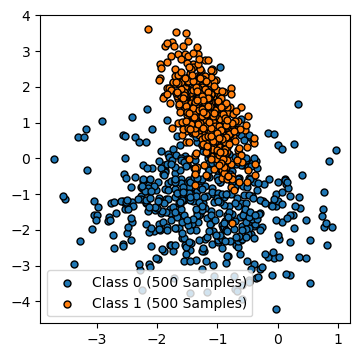

In [30]:
plt.figure(figsize=(4, 4))
X, Y = make_classification(
    n_samples=1000, n_features=2, n_redundant=0, n_informative=2, n_classes=2, n_clusters_per_class=1,
    weights=[0.5, 0.5], class_sep=1.2, random_state=30, shuffle=True, flip_y=0.0
)
for i in range(2):
    dat = X[Y == i]
    plt.scatter(dat[:,0], dat[:,1], label=f"Class {str(i)} ({len(dat)} Samples)", marker="o", s=25, edgecolor="k")
plt.legend()
plt.show()

In [31]:
mask_in = (Y == 0) # Class 0 is in distribution (Class 1 is OOD)
nr_train = 300

X_in = X[mask_in]
Y_in = Y[mask_in]
X_out = X[~mask_in]
Y_out = Y[~mask_in]

X_in_train = X_in[:nr_train]
Y_in_train = Y_in[:nr_train]
X_in_test = X_in[nr_train:]
Y_in_test = Y_in[nr_train:]

X_out_train = X_out[:nr_train]
Y_out_train = Y_out[:nr_train]
X_out_test = X_out[nr_train:]
Y_out_test = Y_out[nr_train:]

print(
    "Train Data In: ", X_in_train.shape, Y_in_train.shape,
    "\nTrain Data Out: ", X_out_train.shape, Y_out_train.shape,
    "\nTest Data In: ", X_in_test.shape, Y_in_test.shape,
    "\nTest Data Out: ", X_out_test.shape, Y_out_test.shape
)

Train Data In:  (300, 2) (300,) 
Train Data Out:  (300, 2) (300,) 
Test Data In:  (200, 2) (200,) 
Test Data Out:  (200, 2) (200,)


In [32]:
X_train = np.concatenate([X_in_train, X_out_train], axis=0)
Y_train = np.concatenate([Y_in_train, Y_out_train], axis=0)
X_test = np.concatenate([X_in_test, X_out_test], axis=0)
Y_test = np.concatenate([Y_in_test, Y_out_test], axis=0)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((600, 2), (600,), (400, 2), (400,))

### Train binary classifier (auxiliary model)

In [33]:
clf = SVC(kernel="rbf", C=1.0)
clf.fit(X_train, Y_train)

# Make predictions on the test set
Y_pred = clf.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(Y_test, Y_pred)
print(f'Accuracy: {accuracy:.2f}')

print('Classification Report:')
print(classification_report(Y_test, Y_pred))

# False Positive Rate
fpr = np.sum((Y_pred == 1) & (Y_test == 0)) / np.sum(Y_test == 0) # (H1|H0) / H0
print(f'False Positive Rate: {fpr:.2f}')

Accuracy: 0.94
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       200
           1       0.92      0.97      0.94       200

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400

False Positive Rate: 0.09


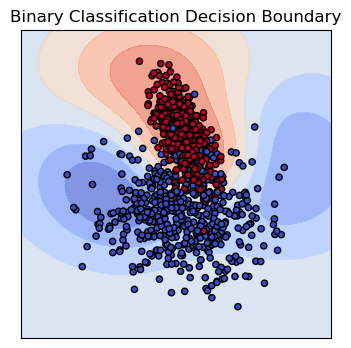

In [34]:
from sklearn.inspection import DecisionBoundaryDisplay

fig, ax = plt.subplots(1, 1)
fig.set_size_inches(4, 4)

disp = DecisionBoundaryDisplay.from_estimator(
    clf,
    X,
    response_method = "decision_function",
    cmap=plt.cm.coolwarm,
    alpha=0.7,
    ax=ax
)
ax.scatter(X[:,0], X[:,1], c=Y, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
ax.set_xticks(())
ax.set_yticks(())
ax.set_title("Binary Classification Decision Boundary")

plt.show()


### Stream setting for testing

In [35]:
# assert len(X_in_test) == len(X_out_test)
T = len(X_in_test)
ood_prob = 0.5

stream_x = np.zeros(shape=(T, 2))
stream_y = np.zeros(T)

for t in range(0, T):
    data_idx = np.random.randint(0, T)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        stream_x[t] = X_in_test[data_idx]
        stream_y[t] = Y_in_test[data_idx]
    elif bern == 1: # out of distribution
        stream_x[t] = X_out_test[data_idx]
        stream_y[t] = Y_out_test[data_idx]

### Stream prediction and evidence collection (E-C2ST)

In [48]:
alpha = 0.1 # target fpr

stream_pred = np.zeros(T)
stream_fpr = np.zeros(T)

stream_eval = np.ones(T)
lam = 0.0
a = 1.0

for t in range(0, T):
    stream_pred[t] = clf.predict(stream_x[t].reshape(1, -1))[0]
    
    # stream_fpr[t] = np.nan_to_num(np.sum((stream_pred[:t+1] == 1) & (stream_y[:t+1] == 0)) / np.sum(stream_y[:t+1] == 0), nan=0.0)
    stream_fpr[t] = np.nan_to_num(np.sum((stream_pred[:t+1] == 1) & (stream_y[:t+1] == 0)) / np.sum(stream_y == 0), nan=0.0)
    
    # E-C2ST
    if (t % 2 == 0) and (t > 0):
        v = (stream_pred[t] - stream_pred[t-1])
        z = v / (1 - v * lam)
        a = a + z**2
        lam = min(0.5, max(-0.5, lam - (2 / 2 - np.log(3)) * (z / a)))
        
        evidence = stream_eval[t-1] * (1 + lam * v)
    else:
        evidence = stream_eval[t-1]
    
    stream_eval[t] = evidence

In [49]:
t_candidate = np.where(stream_fpr >= alpha)[0]
if len(t_candidate) == 0:
    t_opt = T
else:
    t_opt = t_candidate.min()

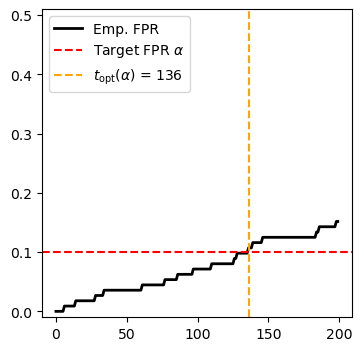

In [50]:
plt.figure(figsize=(4, 4))
plt.plot(stream_fpr, label="Emp. FPR", color="black", lw=2)
plt.axhline(y=alpha, color="red", linestyle="--", label=r"Target FPR $\alpha$")
plt.axvline(x=t_opt, color="orange", linestyle="--", label=r"$t_{\text{opt}}(\alpha)$ = " + str(t_opt))
plt.ylim(-0.01, 0.51)
plt.legend()
plt.show()

In [51]:
t_ev_candidate = np.where(stream_eval >= 1/alpha)[0]
if len(t_ev_candidate) == 0:
    t_ev = T
else:
    t_ev = t_ev_candidate.min()

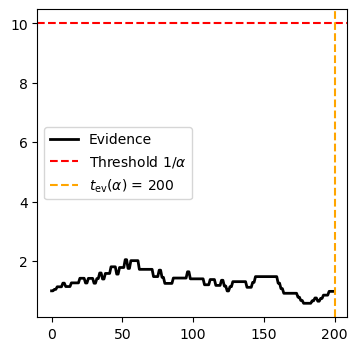

In [52]:
plt.figure(figsize=(4, 4))
plt.plot(stream_eval, label="Evidence", color="black", lw=2)
plt.axhline(y=1/alpha, color="red", linestyle="--", label=r"Threshold $1/\alpha$")
plt.axvline(x=t_ev, color="orange", linestyle="--", label=r"$t_{\text{ev}}(\alpha)$ = " + str(t_ev))
# plt.ylim(-0.01, 4)
plt.legend()
plt.show()